In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("powerplant_data.csv")

In [5]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


AT -> Temperature
V -> Vacuum
AP -> Pressure
RH -> Humidity

PE - > Produced Energy

In [6]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [7]:
X = df.drop("PE", axis = 1)
y = df["PE"]

In [8]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [9]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [10]:
#Split out Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [12]:
df.shape

(9568, 5)

In [13]:
#Scale our input features -> if range of any feature is big it should not dominate out Z value
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [15]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [20]:
# Converting data to Tensor
import torch
import torch.nn as nn #nn - > has inbuilt functionalities of layers, activation func, neurons

# tensor - core data struc of pytorch (multidimensional arrays)
# convert X_train, X_test, y_train, y_test to tensors -> BENEFIT- Pytorch automatically handles gradients, differentiations, dL/dw
X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1,1) # view-(rows, col)---> -1 means automatically detect rows here 7654
#StandardScaler not applied to "y", label vals -> hence used '.values'
# '.view' -> changes dimension 1D-> 2D which pytorch expects

X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1,1)
#these tensors are stored in RAM

In [21]:
type(X_train_scaled) # this is numpy array -> directly converted to float val

numpy.ndarray

In [22]:
type(y_train) # this is pandas series (array -nt) -> cannot be converted directly hence we access its values first

pandas.core.series.Series

In [23]:
y_train # 1D 

5487    442.75
3522    432.52
6916    428.80
7544    426.07
7600    436.58
         ...  
5734    436.44
5191    441.20
5390    464.26
860     440.45
7270    484.44
Name: PE, Length: 7654, dtype: float64

In [24]:
y_train_tensor #2D -> pytorch expects this to work upon

tensor([[442.7500],
        [432.5200],
        [428.8000],
        ...,
        [464.2600],
        [440.4500],
        [484.4400]])

In [25]:
# TensorDataset & DataLoader (TensorDataset class -> access DataLoader class -> access raw data from RAM)
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor) #(input_features, output_features)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [26]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32)

In [27]:
X_train.shape

(7654, 4)

In [28]:
X_train.shape[1] # total number of features- 4

4

# DEEP LEARNING

In [29]:
#Define our ANN Model
#....ANN model built in form of a class on top of base class 'nn.Module' --> 'nn.Module' has all mechanisms of pytorch(FP / BP)
class ANN(nn.Module):
    def __init__(self): #define Constructor -> calls super constructor of 'nn.Module' and initialize nn model
        super(ANN, self).__init__()

        self.model = nn.Sequential( # 'self' -> parameter -> refers to object of ANN class  , 'nn.Sequential'-> gives sequences of layers (i/p, hidden layer, o/p)

            #1st hidden layer
            
            #nn.Linear(in_features , out_features)
            nn.Linear(X_train.shape[1], 6), # Z is calculated by Linear Activation func
            nn.ReLU(), # Apply ReLU Activation func on Z  .... -> Two AP func in same layer

            
            #2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),

            #output layer
            nn.Linear(6, 1), # 6 internel values from 6 diff neurons
                             # on final output layer of regression-> Linear Activation func applied
        )

    def forward(self, x): # Forward Propagation -> to do FP in pytorch we need to write function for it , but in BP pytorch handles automatically by "AutoGrad"
        return self.model(x) #returns the model we defined above

In [30]:
import torch.optim as optim #...-> for optimizer

#actual object / model created here from above class
model = ANN()

#loss func, optimizer
criterion = nn.MSELoss() #-> MSE used in Regression, (on basis of MSE, we figure out or GD curve)--> MSE minimizes, then loss minimizes
optimizer = optim.Adam(model.parameters()) # default optimizer -> 'Adam' -> pass all model parameters (weight, bias --> already done by nn.Module)


#### till here our Model has got the nn architecture but no traning / learning has been done yet. Weight and bias vals are initialized with zero.
#### nn Model learning here means it has learnt the correct vals of weight and bias.

In [31]:
# Train the ANN 
# 1 epoch sees the entire training data at once
#-> through multiple epochs...100 epochs , multiple batches
train_losses = []
val_losses = []
epochs = 100

for epoch in range(epochs):
    model.train() # taking model in training model(learning to adjust weights/back propagration)
    running_loss = 0.0 # total training loss for 1 epoch

    for xb, yb in train_loader: # keep passing batch one by one in neural network then perform FP , BP
        # train_loader -> divides training data into batches
        # xb = input features of 1 batch
        # yb = labels of 1 batch 
        optimizer.zero_grad()

        #1 batch => 1 iteration
        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update

        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    #Validation
    running_val_loss = 0.0

    with torch.no_grad(): # no computation of gradients
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f" epoch {epoch + 1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss} ")

 epoch 1/100 ==> train loss = 206015.12838541667 & val loss = 203682.265625 
 epoch 2/100 ==> train loss = 195070.27649739583 & val loss = 180569.15625 
 epoch 3/100 ==> train loss = 153985.09446614582 & val loss = 122526.4765625 
 epoch 4/100 ==> train loss = 88782.19510904948 & val loss = 58952.17578125 
 epoch 5/100 ==> train loss = 40159.81741536458 & val loss = 27061.994140625 
 epoch 6/100 ==> train loss = 21804.599735514323 & val loss = 17947.375 
 epoch 7/100 ==> train loss = 16145.198775227864 & val loss = 13932.37109375 
 epoch 8/100 ==> train loss = 12525.59643351237 & val loss = 10612.158203125 
 epoch 9/100 ==> train loss = 9391.196872965495 & val loss = 7762.6455078125 
 epoch 10/100 ==> train loss = 6765.936457316081 & val loss = 5510.7900390625 
 epoch 11/100 ==> train loss = 4852.834249877929 & val loss = 3966.52294921875 
 epoch 12/100 ==> train loss = 3500.67458190918 & val loss = 2911.08251953125 
 epoch 13/100 ==> train loss = 2577.9284278869627 & val loss = 2167.9

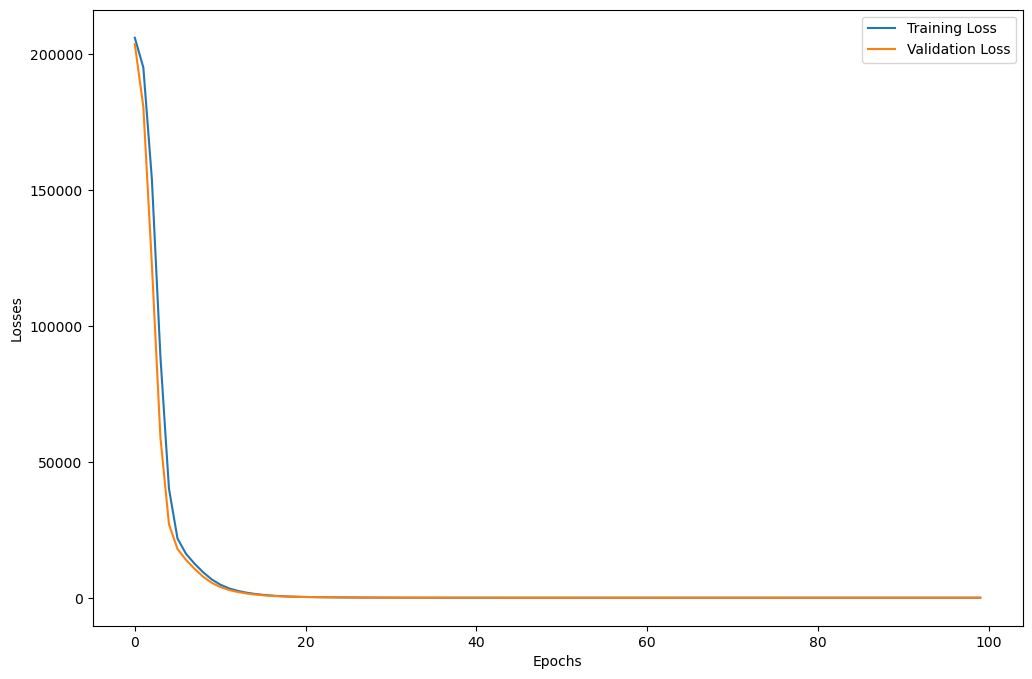

In [36]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.figure(figsize = (12, 8) )
plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()